# CERF Index for Risk and Vulnerability (CIRV) EDA (2020-2025)
This notebook explores the CIRV scores across the different Underfunded Emergencies rounds.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")


## 1. Load Data

In [2]:
data_dir = '../initial_data/cirv'
files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

dataframes = []
for file in files:
    
    # Extract round info from filename, e.g. CERF UFE 2023-I
    match = re.search(r'202\d-[I]+', file)
    if match:
        round_name = match.group()
    else:
        # Some are just 2020-I or 2022-II
        continue
        
    df = pd.read_csv(os.path.join(data_dir, file))
    
    # Find the CIRV score column
    # Often it includes "CIRV" and "score" or is just "CIRV" or "CIRV (Adjusted)"
    cirv_col = None
    country_col = None
    
    for col in df.columns:
        col_lower = str(col).lower()
        if 'cirv' in col_lower and ('adjusted' in col_lower or 'incl inform' in col_lower or 'score' in col_lower):
            cirv_col = col
            break
            
    # Default fallback    
    if cirv_col is None:
        for col in df.columns:
            if str(col).startswith('CIRV'):
                cirv_col = col
                break
                
    for col in df.columns:
        if str(col).lower() in ['country', 'country ', 'country_name']:
            country_col = col
            break
            
    if cirv_col and country_col:
        # Clean df
        temp_df = df[[country_col, cirv_col]].dropna()
        temp_df.columns = ['Country', 'CIRV_Score']
        
        # Make sure they are numerics
        temp_df['CIRV_Score'] = pd.to_numeric(temp_df['CIRV_Score'], errors='coerce')
        temp_df['Country'] = temp_df['Country'].astype(str).str.strip()
        temp_df = temp_df.dropna()
        
        # Remove header artifacts if any
        temp_df = temp_df[temp_df['Country'] != 'Country']
        
        temp_df['Round'] = round_name
        dataframes.append(temp_df)
    else:
        print(f"Could not find CIRV or Country column in {file}")

df_all = pd.concat(dataframes, ignore_index=True)
df_all['Year'] = df_all['Round'].apply(lambda x: int(x.split('-')[0]))
df_all['Half'] = df_all['Round'].apply(lambda x: 1 if x.endswith('-I') else 2)
df_all = df_all.sort_values(by=['Year', 'Half'])

print("Total Records matched:", len(df_all))
df_all.head()


Total Records matched: 1661


,Country,CIRV_Score,Round,Year,Half
453,TEST,100.000000,2020-I,2020,1
454,Afghanistan,70.457083,2020-I,2020,1
455,Albania,12.675000,2020-I,2020,1
456,Algeria,31.013889,2020-I,2020,1
457,Angola,21.255556,2020-I,2020,1


## 2. Distribution Analysis

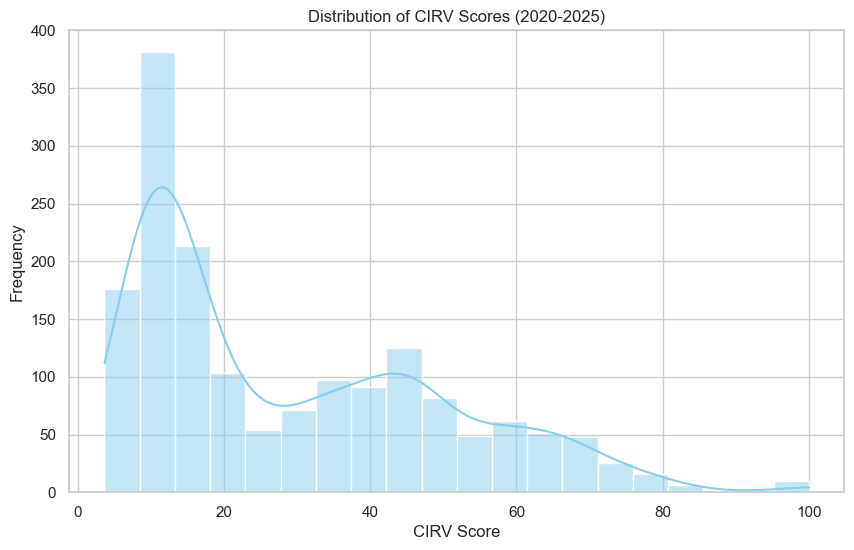

count    1661.000000
mean       29.142356
std        20.891844
min         3.666667
25%        11.333333
50%        21.000000
75%        44.628889
max       100.000000
Name: CIRV_Score, dtype: float64


In [3]:
# Distribution of CIRV Scores
plt.figure(figsize=(10, 6))
sns.histplot(df_all['CIRV_Score'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of CIRV Scores (2020-2025)')
plt.xlabel('CIRV Score')
plt.ylabel('Frequency')
plt.show()

print(df_all['CIRV_Score'].describe())


## 3. Most Vulnerable Countries

/var/folders/hf/80kpwqgj5057_1y4_mx9px8h0000gn/T/ipykernel_43066/4196522490.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries['mean'], palette="Reds_r")


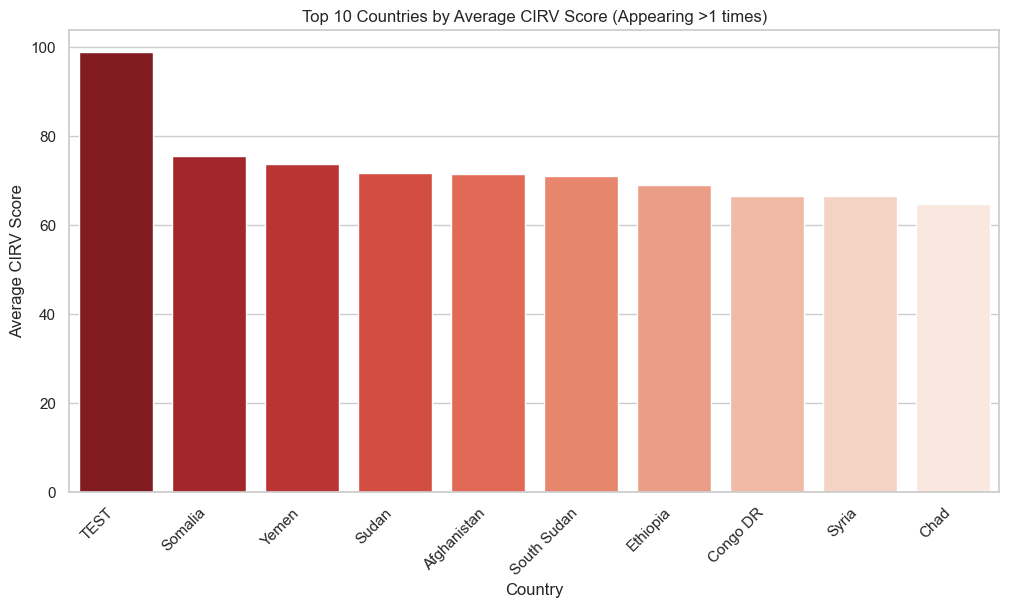

Highest average CIRV scores:
                  mean  count
Country                      
TEST         98.989899     11
Somalia      75.539680     11
Yemen        73.702980     11
Sudan        71.710303     11
Afghanistan  71.611019     11
South Sudan  71.111431     11
Ethiopia     69.054242     11
Congo DR     66.552441     11
Syria        66.534503     11
Chad         64.821919     11


In [4]:
# Top 10 countries with the highest average CIRV scores 
country_avg = df_all.groupby('Country')['CIRV_Score'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
top_countries = country_avg[country_avg['count'] > 1].head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.index, y=top_countries['mean'], palette="Reds_r")
plt.title('Top 10 Countries by Average CIRV Score (Appearing >1 times)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average CIRV Score')
plt.show()

print("Highest average CIRV scores:")
print(top_countries)


## 4. Trend Analysis

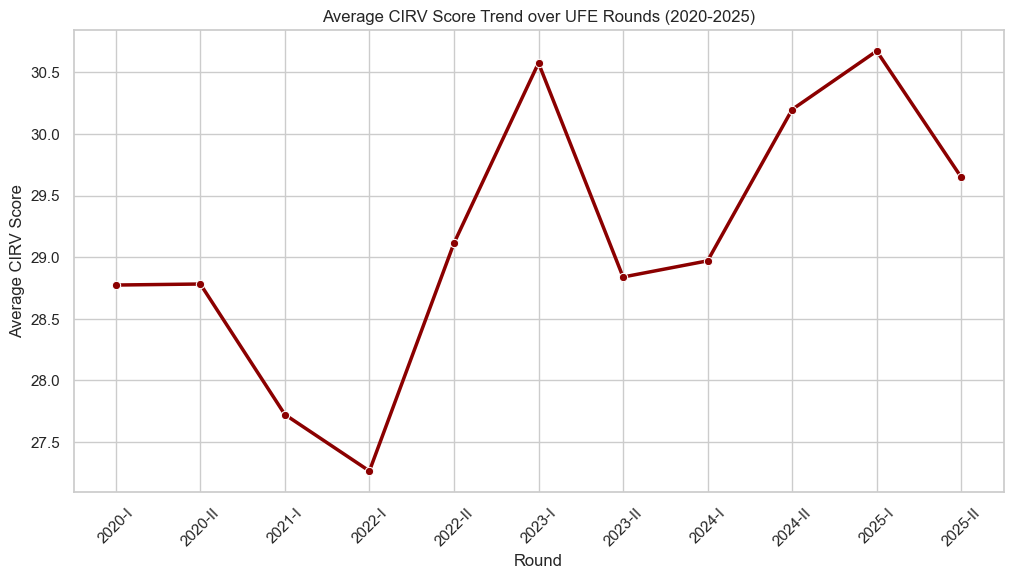

Average CIRV score per round:
      Round  CIRV_Score
0    2020-I   28.774296
1   2020-II   28.782574
2    2021-I   27.723586
3    2022-I   27.265224
4   2022-II   29.113584
5    2023-I   30.575933
6   2023-II   28.839403
7    2024-I   28.970634
8   2024-II   30.198533
9    2025-I   30.672984
10  2025-II   29.649161


In [5]:
# Trend of average CIRV score over the rounds
round_avg = df_all.groupby('Round')['CIRV_Score'].mean().reset_index()

# Sort properly by year and half
round_avg['Year'] = round_avg['Round'].apply(lambda x: int(x.split('-')[0]))
round_avg['Half'] = round_avg['Round'].apply(lambda x: 1 if x.endswith('-I') else 2)
round_avg = round_avg.sort_values(by=['Year', 'Half'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=round_avg, x='Round', y='CIRV_Score', marker='o', linewidth=2.5, color='darkred')
plt.title('Average CIRV Score Trend over UFE Rounds (2020-2025)')
plt.xticks(rotation=45)
plt.ylabel('Average CIRV Score')
plt.grid(True)
plt.show()

print("Average CIRV score per round:")
print(round_avg[['Round', 'CIRV_Score']])

# Let's save a summary locally for the AI to read
with open('../reports/cirv_summary.txt', 'w') as f:
    f.write("--- HIGHEST AVERAGE CIRV SCORES ---\n")
    f.write(top_countries.to_string())
    f.write("\n\n--- CIRV TREND OVER ROUNDS ---\n")
    f.write(round_avg[['Round','CIRV_Score']].to_string())
